In [18]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import pandas as pd

In [19]:
LPF = np.array([1/np.sqrt(2), 1/np.sqrt(2)]) #low-pass filter
HPF = np.array([-1/np.sqrt(2), (1/np.sqrt(2))]) #high-pass filter

In [20]:
def convo_h(image, kernel):
    ukuran_kernel = len(kernel)
    pad_width = ukuran_kernel // 2
    padd = np.pad(image, ((0, 0), (pad_width, pad_width)), mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))

    for i in range(len(conv)):
        for j in range(len(conv[i])):
            for x in range(len(kernel)):
                conv[i][j] += padd[i][j + x] * kernel[x]
    return conv

def convo_h(image, kernel):
    ukuran_kernel = len(kernel)
    pad_width = ukuran_kernel // 2

    padd = np.pad(
        image,
        ((0,0),(pad_width,pad_width)),
        mode='constant'
    )

    conv = np.zeros(image.shape)

    for i in range(conv.shape[0]):
        for j in range(conv.shape[1]):
            for x in range(ukuran_kernel):
                conv[i,j] += (
                    padd[i,j+x]
                    * kernel[ukuran_kernel-1-x]
                )

    return conv

def convo_v(image, kernel):
    ukuran_kernel = len(kernel)
    pad_width = ukuran_kernel // 2
    padd = np.pad(image, ((pad_width, pad_width), (0, 0)), mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))
    for i in range(len(conv)):
        for j in range(len(conv[i])):
            for x in range(len(kernel)):
                conv[i][j] += padd[i + x][j] * kernel[x]
    return conv

def downsampling_h(image):
    downsampled = np.zeros((image.shape[0], image.shape[1] // 2))
    for i in range(len(downsampled)):
        indeks = 0
        for j in range(len(downsampled[i])):
            downsampled[i][j] = image[i][indeks]
            indeks += 2
    return downsampled

def downsampling_v(image):
    baris = int(image.shape[0] / 2)
    kolom = int(image.shape[1])
    downsampled = np.zeros((baris, kolom))
    indeks = 0
    for i in range(baris):
        for j in range(kolom):
            downsampled[i][j] = image[indeks][j]
        indeks += 2
    return downsampled

def normalisasi(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val == min_val:
        return np.zeros(image.shape)
    return (image - min_val) / (max_val - min_val) * 255

def wavelet(image):
    # LL (Approximation)
    konvolusi1 = convo_h(image, LPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, LPF)
    approximation = downsampling_v(konvolusi2)
    approximation = normalisasi(approximation)

    # LH (Horizontal Detail)
    konvolusi1 = convo_h(image, LPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, HPF)
    horizontal = downsampling_v(konvolusi2)
    horizontal = normalisasi(horizontal)

    # HL (Vertical Detail)
    konvolusi1 = convo_h(image, HPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, LPF)
    vertikal = downsampling_v(konvolusi2)
    vertikal = normalisasi(vertikal)

    # HH (Diagonal Detail)
    konvolusi1 = convo_h(image, HPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, HPF)
    diagonal = downsampling_v(konvolusi2)
    diagonal = normalisasi(diagonal)

    return (approximation, horizontal, vertikal, diagonal)

In [21]:
def upsampling_v(image):
    upsampled = np.zeros((image.shape[0] * 2, image.shape[1]))
    for i in range(len(image)):
        for j in range(len(image[i])):
            upsampled[i * 2][j] = image[i][j]
    return upsampled

def upsampling_h(image):
    upsampled = np.zeros((image.shape[0], image.shape[1] * 2))
    for i in range(len(image)): 
        for j in range(len(image[i])):
            upsampled[i][j * 2] = image[i][j]
    return upsampled

def rekonstruksi(LL, LH, HL, HH, LPF, HPF):
    upsampling = upsampling_v(LL)
    konvolusiL = convo_v(upsampling, LPF)

    upsampling = upsampling_v(LH)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling = upsampling_h(konvolusiL + konvolusiH)
    konvolusiL2 = convo_h(upsampling, LPF)

    upsampling = upsampling_v(HL)
    konvolusiL = convo_v(upsampling, LPF)

    upsampling = upsampling_v(HH)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling = upsampling_h(konvolusiL + konvolusiH)
    konvolusiH2 = convo_h(upsampling, HPF)

    hasil = konvolusiL2 + konvolusiH2
    return hasil

In [22]:
def graycomatrix(image, distances, angles, levels=256, symmetric=True, normed=True):
    angle = angles[0]

    if angle == 0:
        dr, dc = 0, 1
    elif angle == np.pi / 4:
        dr, dc = -1, 1
    elif angle == np.pi / 2:
        dr, dc = -1, 0
    elif angle == 3 * np.pi / 4:
        dr, dc = -1, -1

    glcm_matrix = np.zeros((levels, levels))
    h, w = image.shape

    for i in range(h):
        for j in range(w):
            row_tetangga = i + dr
            col_tetangga = j + dc

            if 0 <= row_tetangga < h and 0 <= col_tetangga < w:
                ref_pixel = int(image[i][j])
                neighbor_pixel = int(image[row_tetangga][col_tetangga])
                glcm_matrix[ref_pixel][neighbor_pixel] += 1

    if symmetric:
        glcm_matrix = glcm_matrix + glcm_matrix.T

    if normed:
        total = np.sum(glcm_matrix)
        if total > 0:
            glcm_matrix = glcm_matrix / total

    return np.reshape(glcm_matrix, (levels, levels, 1, 1))


def graycoprops(matriks, prop):
    glcm = matriks[:, :, 0, 0]
    levels = glcm.shape[0]

    i_indices, j_indices = np.ogrid[:levels, :levels]

    if prop == 'contrast':
        weights = (i_indices - j_indices) ** 2
        hasil = np.sum(glcm * weights)

    elif prop == 'dissimilarity':
        weights = np.abs(i_indices - j_indices)
        hasil = np.sum(glcm * weights)

    elif prop == 'homogeneity':
        weights = 1.0 / (1.0 + (i_indices - j_indices) ** 2)
        hasil = np.sum(glcm * weights)

    elif prop == 'ASM':
        hasil = np.sum(glcm ** 2)

    elif prop == 'energy':
        hasil = np.sqrt(np.sum(glcm ** 2))

    elif prop == 'correlation':
        mean_i = np.sum(i_indices * glcm)
        mean_j = np.sum(j_indices * glcm)

        std_i = np.sqrt(np.sum(((i_indices - mean_i) ** 2) * glcm))
        std_j = np.sqrt(np.sum(((j_indices - mean_j) ** 2) * glcm))

        if std_i == 0 or std_j == 0:
            hasil = 0
        else:
            titik_tengah = (i_indices - mean_i) * (j_indices - mean_j)
            hasil = np.sum(glcm * titik_tengah) / (std_i * std_j)

    return np.array([[hasil]])

def entropy(elemen_matriks):
    p = elemen_matriks[elemen_matriks > 0]

    if len(p) == 0:
        return 0.0

    return -np.sum(p * np.log2(p))

# from skimage.feature import graycomatrix, graycoprops
# from scipy.stats import entropy

In [23]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [24]:
def upsampling_v(image):
    upsampled = np.zeros((image.shape[0] * 2, image.shape[1]))
    for i in range(len(image)):
        for j in range(len(image[i])):
            upsampled[i * 2][j] = image[i][j]
    return upsampled

def upsampling_h(image):
    upsampled = np.zeros((image.shape[0], image.shape[1] * 2))
    for i in range(len(image)):
        for j in range(len(image[i])):
            upsampled[i][j * 2] = image[i][j]
    return upsampled

def rekonstruksi(LL, LH, HL, HH, LPF, HPF):
    upsampling = upsampling_v(LL)
    konvolusiL = convo_v(upsampling, LPF)

    upsampling = upsampling_v(LH)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling = upsampling_h(konvolusiL + konvolusiH)
    konvolusiL2 = convo_h(upsampling, LPF)

    upsampling = upsampling_v(HL)
    konvolusiL = convo_v(upsampling, LPF)

    upsampling = upsampling_v(HH)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling = upsampling_h(konvolusiL + konvolusiH)
    konvolusiH2 = convo_h(upsampling, HPF)

    hasil = konvolusiL2 + konvolusiH2
    return hasil

# hasil = rekonstruksi(approximation, horizontal, vertikal, diagonal, LPF, HPF)

In [25]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

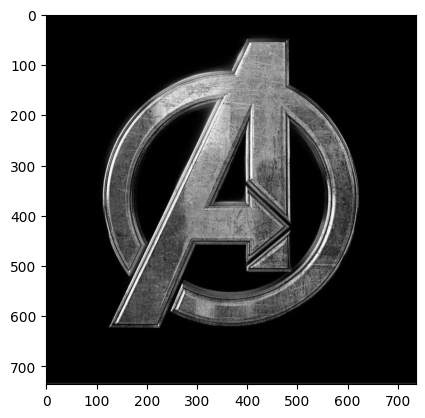

In [26]:
doomsday = cv.imread('doomsday.jpg')
doomsdayGray = cv.cvtColor(doomsday, cv.COLOR_BGR2GRAY)
plt.imshow(doomsdayGray, cmap='gray')

In [27]:
ll_dom, lh_dom, hl_dom, hh_dom = wavelet(doomsdayGray)

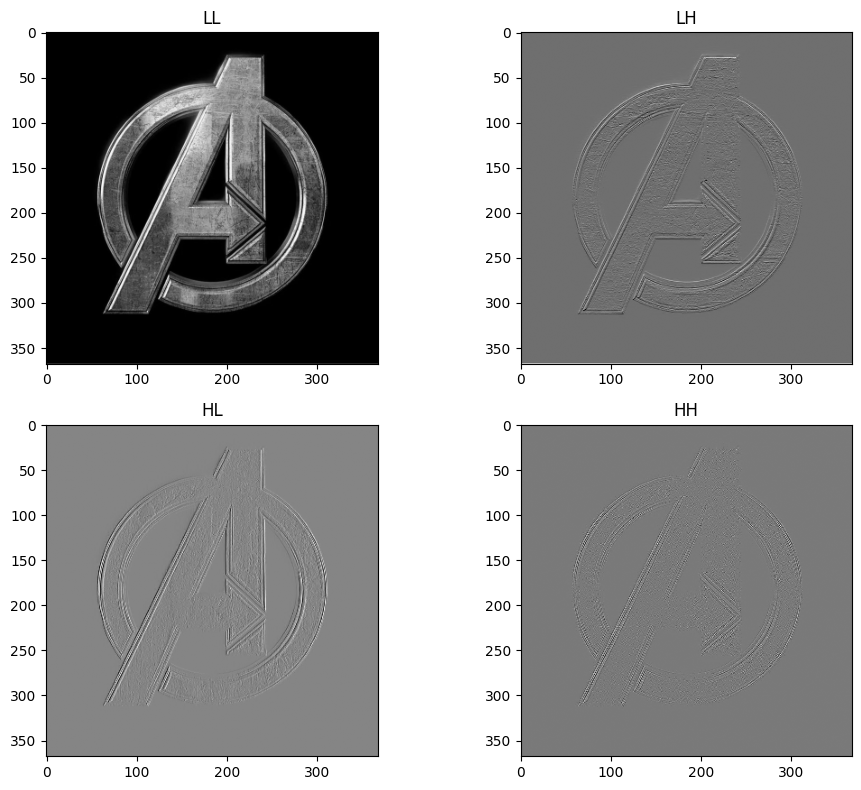

In [28]:
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(ll_dom, cmap='gray')
plt.title('LL')

plt.subplot(2,2,2)
plt.imshow(lh_dom, cmap='gray')
plt.title('LH')

plt.subplot(2,2,3)
plt.imshow(hl_dom, cmap='gray')
plt.title('HL')

plt.subplot(2,2,4)
plt.imshow(hh_dom, cmap='gray')
plt.title('HH')

plt.tight_layout()
plt.show()

In [29]:
def Thresholding(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):
            if img[i,j] >= batas:
                canvas[i,j] = 255
            elif img[i,j] <= batas:
                canvas[i,j] = 0
    return canvas

In [30]:
def Resize(image, new_width, new_height):
    old_height, old_width = image.shape[:2]
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized_image[i, j] = image[y, x]
    return resized_image

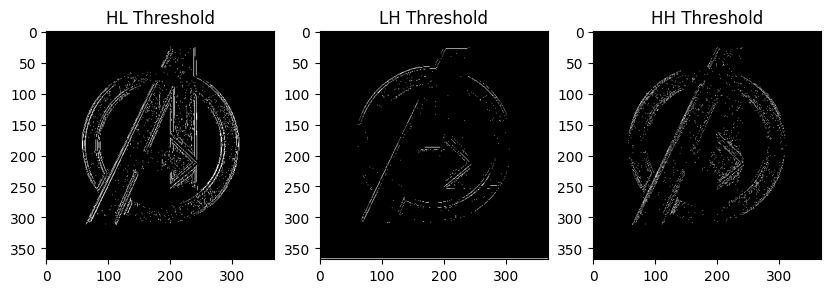

In [37]:
HL_resize = cv.resize(hl_dom, (256, 256))
LH_resize = cv.resize(lh_dom, (256, 256))
HH_resize = cv.resize(hh_dom, (256, 256))

HL_tr = Thresholding(hl_dom, 150)
LH_tr = Thresholding(lh_dom, 150)
HH_tr = Thresholding(hh_dom, 150)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(HL_tr, cmap='gray')
plt.title('HL Threshold')

plt.subplot(1,3,2)
plt.imshow(LH_tr, cmap='gray')
plt.title('LH Threshold')

plt.subplot(1,3,3)
plt.imshow(HH_tr, cmap='gray')
plt.title('HH Threshold')

plt.show()

In [32]:
def Dilasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))

    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i+k-center, j+l-center] = 255
            else:
                if hasil[i, j] != 255:
                    hasil[i, j] = 0

    return hasil


def Erosi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width), dtype=np.uint8)

    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i+k-center, j+l-center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255

    return hasil

def closing(image, kernel):
    return Erosi(Dilasi(image, kernel), kernel)


In [33]:
kernel5 = np.array ([[0, 0, 1, 0, 0],
                     [0, 1, 1, 1, 0],
                     [1, 1, 1, 1, 1],
                     [0, 1, 1, 1, 0],
                     [0, 0, 1, 0, 0]])

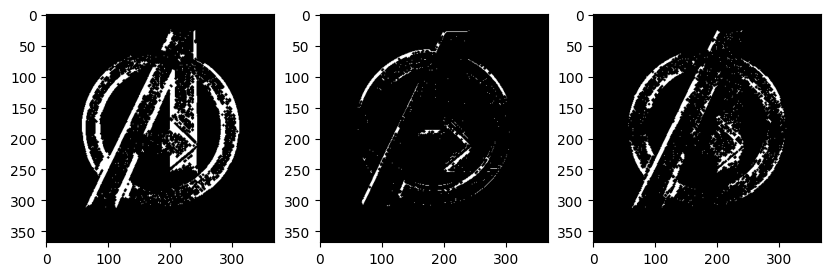

In [34]:
HL_cl = closing(HL_tr, kernel5)
LH_cl = closing(LH_tr, kernel5)
HH_cl = closing(HH_tr, kernel5)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(HL_cl, cmap='gray')

plt.subplot(1,3,2)
plt.imshow(LH_cl, cmap='gray')

plt.subplot(1,3,3)
plt.imshow(HH_cl, cmap='gray')

plt.show()

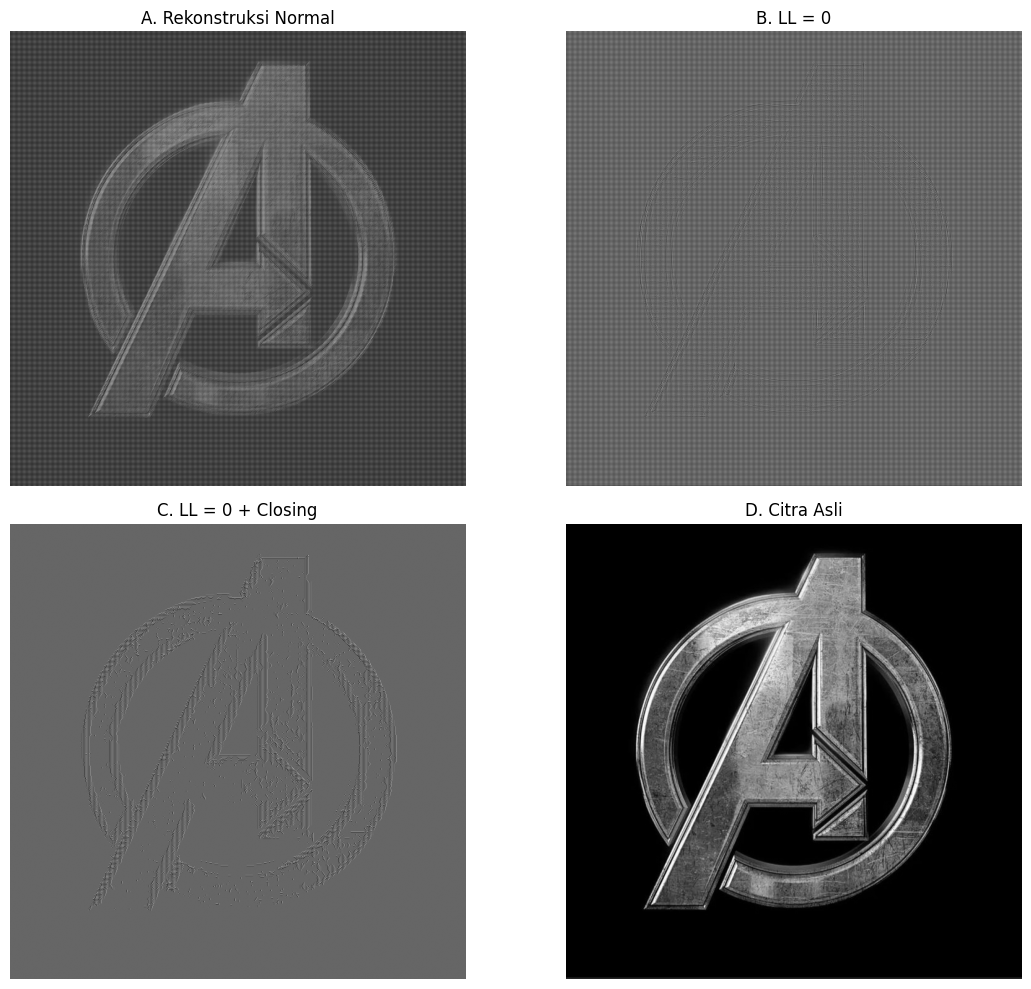

In [38]:
hasil_a = rekonstruksi(ll_dom, hl_dom, lh_dom, hh_dom, LPF, HPF)
LL0 = np.zeros_like(ll_dom)
hasil_b = rekonstruksi(LL0, lh_dom, hl_dom, hh_dom, LPF, HPF)
hasil_c = rekonstruksi(LL0, LH_cl, HL_cl, HH_cl, LPF, HPF)

plt.figure(figsize=(12,10))

# a
plt.subplot(2,2,1)
plt.imshow(hasil_a, cmap='gray')
plt.title('A. Rekonstruksi Normal')
plt.axis('off')

# b
plt.subplot(2,2,2)
plt.imshow(hasil_b, cmap='gray')
plt.title('B. LL = 0')
plt.axis('off')

# c
plt.subplot(2,2,3)
plt.imshow(hasil_c, cmap='gray')
plt.title('C. LL = 0 + Closing')
plt.axis('off')

# d
plt.subplot(2,2,4)
plt.imshow(doomsdayGray, cmap='gray')
plt.title('D. Citra Asli')
plt.axis('off')

plt.tight_layout()
plt.show()